# Import Library

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_ai4i_data

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
output_dir = '../reports/figures'
os.makedirs(output_dir, exist_ok=True)

# Load Dataset

In [3]:
df = load_ai4i_data()
display(df.head())

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Target Imbalance Analysis

Proportion of normal operations vs machine failures to understand the baseline class imbalance.

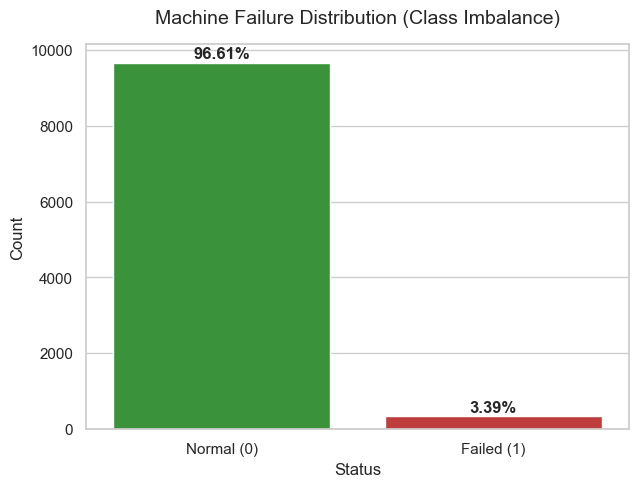

In [4]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='machine_failure', palette=['#2ca02c', '#d62728'])

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=12)

plt.title("Machine Failure Distribution (Class Imbalance)", fontsize=14, pad=15)
plt.xticks([0, 1], ['Normal (0)', 'Failed (1)'])
plt.ylabel("Count")
plt.xlabel("Status")

file_path = os.path.join(output_dir, "target_imbalance.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Severe Class Imbalance:** The target variable, *machine_failure*, exhibits a highly imbalanced distribution. Normal operating conditions account for **96.61%** of the observations, while machine failures represent only **3.39%**. This indicates that failure events are relatively rare compared to normal machine operations.

- **Implications for Predictive Modeling:** The pronounced class imbalance suggests that special consideration will be required during the modeling stage. Appropriate evaluation metrics beyond overall accuracy, as well as suitable imbalance-handling techniques, will be explored to ensure that the predictive models can effectively identify the minority failure class.

# Specific Failure Distrbution

Identifying which mode causes the most breakdowns 

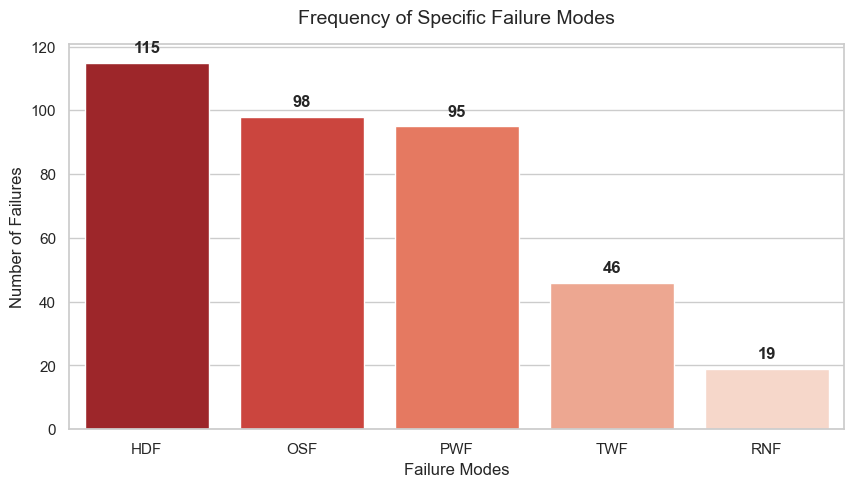

In [5]:
failure_modes = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
failure_counts = df[failure_modes].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=failure_counts.index.str.upper(), y=failure_counts.values, palette='Reds_r')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontweight='bold', fontsize=12, xytext=(0, 5), textcoords='offset points')

plt.title("Frequency of Specific Failure Modes", fontsize=14, pad=15)
plt.ylabel("Number of Failures")
plt.xlabel("Failure Modes")

file_path = os.path.join(output_dir, "specific_failure_modes.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Dominant Failure Modes:** The distribution of failure modes shows that **Heat Dissipation Failure (HDF)** is the most frequent failure type (**115 cases**), followed by **Overstrain Failure (OSF)** (**98 cases**) and **Power Failure (PWF)** (**95 cases**). This indicates that thermal conditions and mechanical loading are among the most common factors associated with machine failures in the dataset.

- **Less Frequent Failure Modes:** **Tool Wear Failure (TWF)** accounts for **46 cases**, while **Random Failures (RNF)** are the least common with only **19 cases**. The relatively low occurrence of RNF is consistent with its definition as an unpredictable failure mode that is not directly associated with specific operating conditions.

- **Implications for Predictive Modeling:** The uneven distribution of failure modes suggests that different failure mechanisms contribute to the overall *machine_failure* target. These characteristics will be considered during the model development stage to ensure that the predictive models can effectively capture the diverse failure patterns.